# 01 — Data Pipeline

**Goal:** Load raw data from two sources, merge them, resample to 3 timeframes, and save to `data/processed/`.

| Step | Description |
|---|---|
| 1 | Load Kaggle CSV (2019-2021, minute-level) |
| 2 | Fetch Binance REST API (2021-present, minute-level) |
| 3 | Merge & deduplicate (Binance takes priority on overlaps) |
| 4 | Resample to 5m, 15m, 30m, 1h |
| 5 | Save `btc_5m.csv`, `btc_15m.csv`, `btc_30m.csv`, `btc_1h.csv` |

In [4]:
import sys
from pathlib import Path

# Make sure the project root is on the path
# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import (
    load_kaggle_csv,
    fetch_binance_klines,
    merge_sources,
    resample_ohlcv,
    save_processed,
    run_pipeline,
)

## 1. Load Kaggle CSV

Download from [Kaggle Bitcoin Historical Data](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data)  
Place the CSV file in `data/raw/` before running this cell.

In [3]:
KAGGLE_PATH = ROOT / 'data' / 'raw' / 'btcusd_1-min_data.csv'

kaggle_df = load_kaggle_csv(KAGGLE_PATH)
print(f"\nShape: {kaggle_df.shape}")
kaggle_df.head()

[data] Loading Kaggle CSV from /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/data/raw/btcusd_1-min_data.csv …
[data] Kaggle CSV: 3,790,364 rows  (2019-01-01 → 2026-03-18)

Shape: (3790364, 5)


,open,high,low,close,volume
timestamp,,,,,
2019-01-01 00:00:00+00:00,3750.62,3752.01,3750.62,3752.01,1.243647
2019-01-01 00:01:00+00:00,3752.01,3752.01,3752.01,3752.01,0.000000
2019-01-01 00:02:00+00:00,3752.01,3752.01,3752.01,3752.01,0.000000
2019-01-01 00:03:00+00:00,3752.01,3752.01,3752.01,3752.01,0.000000
2019-01-01 00:04:00+00:00,3750.31,3750.31,3750.31,3750.31,0.359107


In [3]:
# Check for gaps and basic stats
print("Date range:", kaggle_df.index[0], "→", kaggle_df.index[-1])
print("\nNull counts:")
print(kaggle_df.isnull().sum())
print("\nBasic stats:")
kaggle_df.describe().round(2)

NameError: name 'kaggle_df' is not defined

## 2. Fetch Binance Klines (2021 → present)

Uses the public Binance REST API — no API key required.  
This will take a few minutes due to pagination (~1000 candles per request).

In [8]:
binance_df = fetch_binance_klines(start='2021-01-01')
print(f"\nShape: {binance_df.shape}")
binance_df.tail()

[data] Fetching Binance BTCUSDT 1m klines 2021-01-01 → 2026-03-24 …


KeyboardInterrupt: 

## 3. Merge Sources

In [6]:
merged_df = merge_sources(kaggle_df, binance_df)
print(f"\nMerged shape: {merged_df.shape}")
merged_df.head()

NameError: name 'binance_df' is not defined

NameError: name 'merged_df' is not defined

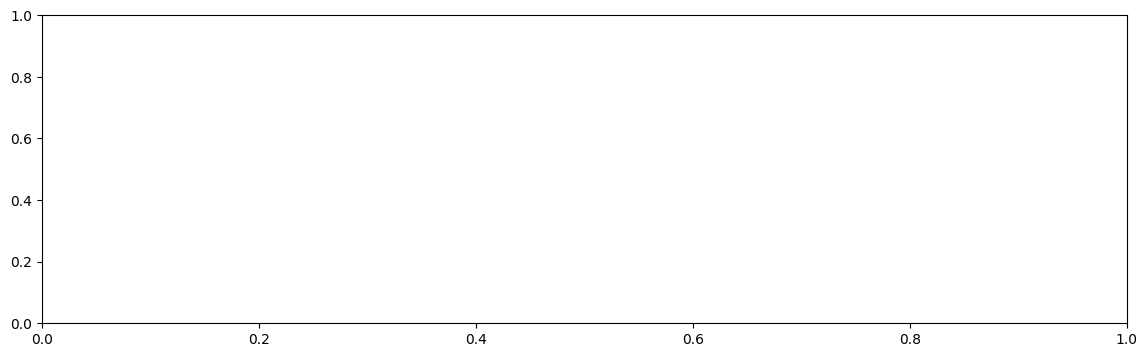

In [16]:
# Visualise the price across the full history
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(merged_df.index, merged_df['close'], linewidth=0.5, color='steelblue')
ax.set_title('BTC/USD — Full Minute-Level History (merged)')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

## 4. Resample to 5m / 15m / 30m / 1h

In [9]:
frames = resample_ohlcv(merged_df)

for label, df in frames.items():
    print(f"\n--- {label} ---")
    display(df.tail(3))

NameError: name 'merged_df' is not defined

## 5. Save to data/processed/

In [7]:
save_processed(frames, out_dir=ROOT / 'data' / 'processed')

# Verify the saved files
for f in sorted((ROOT / 'data' / 'processed').glob('btc_*.csv')):
    df_check = pd.read_csv(f, index_col='timestamp', parse_dates=True)
    print(f"{f.name:20s}  rows={len(df_check):,}  "
          f"{df_check.index[0].date()} → {df_check.index[-1].date()}")

NameError: name 'frames' is not defined

## 6. Enrich with Taker Buy Ratio

Fetches taker buy volume from Binance at each timeframe and computes:

**taker_buy_ratio = taker_buy_base / total_volume**

Values near 1.0 = aggressive buyers dominating. Near 0.0 = sellers. Near 0.5 = balanced.
Rows before Binance coverage (Kaggle 2019-2021 period) are filled with 0.5 (neutral).

In [5]:
from src.data import enrich_with_taker_buy_ratio, save_processed

# Load existing processed CSVs (no need to re-run full pipeline)
existing_frames = {}
for label in ["5m", "15m", "30m", "1h"]:
    existing_frames[label] = pd.read_csv(
        ROOT / "data" / "processed" / f"btc_{label}.csv",
        index_col="timestamp", parse_dates=True
    )

# Enrich with taker buy ratio and overwrite CSVs
enriched_frames = enrich_with_taker_buy_ratio(existing_frames, binance_start="2021-01-01")
save_processed(enriched_frames, out_dir=ROOT / "data" / "processed")
print("Done — taker_buy_ratio added to all processed CSVs.")

[data] Fetching taker_buy_ratio  5m  2021-01-01 → 2026-03-24 …
[data]   … 549,292 candles
[data] taker_buy_ratio 5m: 549,292 candles  (2021-01-01 → 2026-03-24)
[data] 5m: filled 210,741 pre-Binance rows with 0.5
[data] 5m: taker_buy_ratio  mean=0.491  min=0.000  max=0.983
[data] Fetching taker_buy_ratio  15m  2021-01-01 → 2026-03-24 …
[data]   … 183,099 candles
[data] taker_buy_ratio 15m: 183,099 candles  (2021-01-01 → 2026-03-24)
[data] 15m: filled 70,246 pre-Binance rows with 0.5
[data] 15m: taker_buy_ratio  mean=0.492  min=0.000  max=0.943
[data] Fetching taker_buy_ratio  30m  2021-01-01 → 2026-03-24 …
[data]   … 91,552 candles
[data] taker_buy_ratio 30m: 91,552 candles  (2021-01-01 → 2026-03-24)
[data] 30m: filled 35,121 pre-Binance rows with 0.5
[data] 30m: taker_buy_ratio  mean=0.492  min=0.000  max=0.881
[data] Fetching taker_buy_ratio  1h  2021-01-01 → 2026-03-24 …
[data]   … 45,779 candles
[data] taker_buy_ratio 1h: 45,779 candles  (2021-01-01 → 2026-03-24)
[data] 1h: filled 1

## 7. Enrich with Fear & Greed Index

Fetches the daily Bitcoin Fear & Greed Index from [alternative.me](https://alternative.me/crypto/fear-and-greed-index/) (free, no API key).

- **0–24** = Extreme Fear  
- **25–49** = Fear  
- **50** = Neutral  
- **51–74** = Greed  
- **75–100** = Extreme Greed

Forward-filled from daily to candle-level timestamps.

In [ ]:
from src.data import enrich_with_fear_greed, save_processed

# Load current processed CSVs (already have taker_buy_ratio)
current_frames = {}
for label in ["5m", "15m", "30m", "1h"]:
    current_frames[label] = pd.read_csv(
        ROOT / "data" / "processed" / f"btc_{label}.csv",
        index_col="timestamp", parse_dates=True
    )

# Add fear_greed column and overwrite CSVs
enriched_fg = enrich_with_fear_greed(current_frames)
save_processed(enriched_fg, out_dir=ROOT / "data" / "processed")
print("
Done — fear_greed added to all processed CSVs.")

---
## Alternative: Run the entire pipeline in one call

```python
frames = run_pipeline(
    kaggle_path='data/raw/btcusd_1-min_data.csv',
    out_dir='data/processed',
    binance_start='2021-01-01',
)
```

Or from the terminal:
```bash
python -m src.data --kaggle data/raw/btcusd_1-min_data.csv
```